In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
import plotly.express as px

### EXPLORACIÓN DE DATOS

In [3]:
# Cargamos dataset
gym = pd.read_csv("gym_churn_us.csv")
# Valore ausentes?
print(gym.info())
pd.set_option('display.max_columns', None)
display(gym.head(5))
# Duplicados?
filas_duplicadas = gym[gym.duplicated()]
print(filas_duplicadas)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


Empty DataFrame
Columns: [gender, Near_Location, Partner, Promo_friends, Phone, Contract_period, Group_visits, Age, Avg_additional_charges_total, Month_to_end_contract, Lifetime, Avg_class_frequency_total, Avg_class_frequency_current_month, Churn]
Index: []


Advierto que mi data frame no contiene valores ausentes y tampoco filas duplicadas. Todos los valores son numericos, la mayoría enteros pero algunos flotantes. La mayoría de variables son binarias.

In [4]:
print(gym.describe().T) 

                                    count        mean        std        min  \
gender                             4000.0    0.510250   0.499957   0.000000   
Near_Location                      4000.0    0.845250   0.361711   0.000000   
Partner                            4000.0    0.486750   0.499887   0.000000   
Promo_friends                      4000.0    0.308500   0.461932   0.000000   
Phone                              4000.0    0.903500   0.295313   0.000000   
Contract_period                    4000.0    4.681250   4.549706   1.000000   
Group_visits                       4000.0    0.412250   0.492301   0.000000   
Age                                4000.0   29.184250   3.258367  18.000000   
Avg_additional_charges_total       4000.0  146.943728  96.355602   0.148205   
Month_to_end_contract              4000.0    4.322750   4.191297   1.000000   
Lifetime                           4000.0    3.724750   3.749267   0.000000   
Avg_class_frequency_total          4000.0    1.87902

Mediante el estadística descriptiva podemos ver que aproximadamente el 50% los suscriptores son mujeres. Así mismo la gran mayoría viven cerca del gimnasio y a su vez, cerca del 50% de los afiliados hacen parte de las empresas asociadas al gimnasio y el 30% utilizó el descuento de afiliación por amigo cercano. La gran mayoría de los usuarios (75%) cuenta con un contrato de 1 mes. Podemos ver que un gran número de usuarios valoran las clases grupales (más del 40%). El rango de edad es muy variado (entre los 18 y 41 años). Históricamente, los usuarios van en promedio 2 veces por semana al gimnasio.

El diccionario del dataset no espcifica el significado del 0 y 1 de las variables, sin embargo, asumiendo que para la variable Churn 0 (cero) permanencia en el gym y 1 (uno) suspención de suscripción, el 26% de los usuarios ha cancelado la suscripción, aproximadamente 1040 personas.

In [5]:
# Estudio la estadistica para cada grupo: cancelación y continuación de la suscripción
churn_0 = gym[gym["Churn"]==0]
print(churn_0.describe().T)  
churn_0[["Lifetime"]].describe().T

                                    count        mean        std        min  \
gender                             2939.0    0.510037   0.499984   0.000000   
Near_Location                      2939.0    0.873086   0.332933   0.000000   
Partner                            2939.0    0.534195   0.498914   0.000000   
Promo_friends                      2939.0    0.353522   0.478144   0.000000   
Phone                              2939.0    0.903709   0.295040   0.000000   
Contract_period                    2939.0    5.747193   4.716942   1.000000   
Group_visits                       2939.0    0.464103   0.498795   0.000000   
Age                                2939.0   29.976523   3.009933  19.000000   
Avg_additional_charges_total       2939.0  158.445715  99.801599   0.171862   
Month_to_end_contract              2939.0    5.283089   4.363522   1.000000   
Lifetime                           2939.0    4.711807   3.874780   0.000000   
Avg_class_frequency_total          2939.0    2.02487

,count,mean,std,min,25%,50%,75%,max
Lifetime,2939.0,4.711807,3.87478,0.0,2.0,4.0,6.0,31.0


In [6]:
churn_1 = gym[gym["Churn"]==1]  
print(churn_1.describe().T)
churn_1[["Lifetime"]].describe().T 

                                    count        mean        std        min  \
gender                             1061.0    0.510839   0.500118   0.000000   
Near_Location                      1061.0    0.768143   0.422217   0.000000   
Partner                            1061.0    0.355325   0.478837   0.000000   
Promo_friends                      1061.0    0.183789   0.387495   0.000000   
Phone                              1061.0    0.902922   0.296204   0.000000   
Contract_period                    1061.0    1.728558   2.132371   1.000000   
Group_visits                       1061.0    0.268615   0.443448   0.000000   
Age                                1061.0   26.989632   2.895163  18.000000   
Avg_additional_charges_total       1061.0  115.082899  77.696419   0.148205   
Month_to_end_contract              1061.0    1.662582   1.964593   1.000000   
Lifetime                           1061.0    0.990575   1.110799   0.000000   
Avg_class_frequency_total          1061.0    1.47499

,count,mean,std,min,25%,50%,75%,max
Lifetime,1061.0,0.990575,1.110799,0.0,0.0,1.0,1.0,9.0


Al comparar los promedios de las variables por cada grupo (cancelación y permanencia) advertimos que las estrategias como las alianzas o códigos de descuento por amigos sí son efectivas. El 53% de los usuarios y 35% de los usuarios que permanecieron en el gimnasio utilizaron la alianza de la empresa y el códgio de amistad respectivamente, mientras que en el grupo de cancelación estos porcentajes fueron de 35% y 18%. Así mismo, la estadística descriptiva parece indicar que la cercanía al gimnasio sí es un factor decisivo en la permanencia de los usuarios. Resalta el hecho que el tiempo  de contrato promedio de aquellos que permanecen suscritos es mayor (5.7 meses) que del grupo que cancelan (1.7 meses).

HISTOGRAMAS

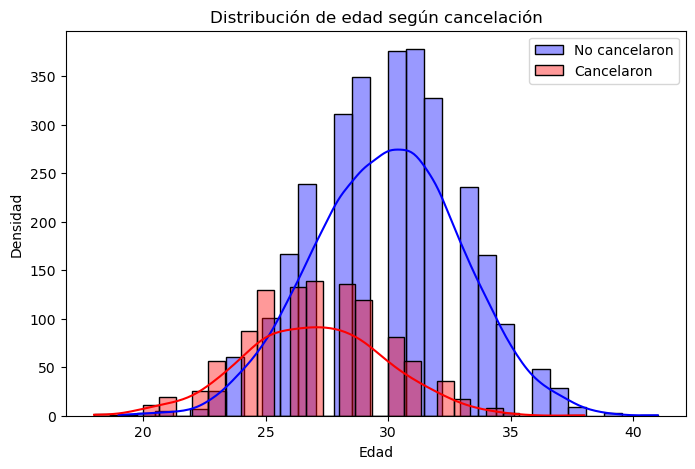

In [7]:
Age_0 = churn_0["Age"]
Age_1 = churn_1["Age"]

plt.figure(figsize=(8,5))

# Histogramas con línea de frecuencia
sns.histplot(Age_0, bins=30, kde=True, color='blue', label='No cancelaron', stat='count', alpha=0.4)
sns.histplot(Age_1, bins=30, kde=True, color='red', label='Cancelaron', stat='count', alpha=0.4)

plt.xlabel('Edad')
plt.ylabel('Densidad')
plt.title('Distribución de edad según cancelación')
plt.legend()
plt.show()


Los histogramas nos permiten ver que la mayoría de personas que permanecen suscritos al gimnasio son de 30 años, mientras que el pico del grupo de personas que cancelaron el servicio está en los 26-27 años. Esto podría indicar que las personas más cercanas a los 30 se sienten más comprometidos con su salud y actividad física. Así mismo, pueden presentar mayor estabilidad económica (al estar trabajando en empresas aliadas) y por consecuencia mayor facilidad para la compra de este servicio.

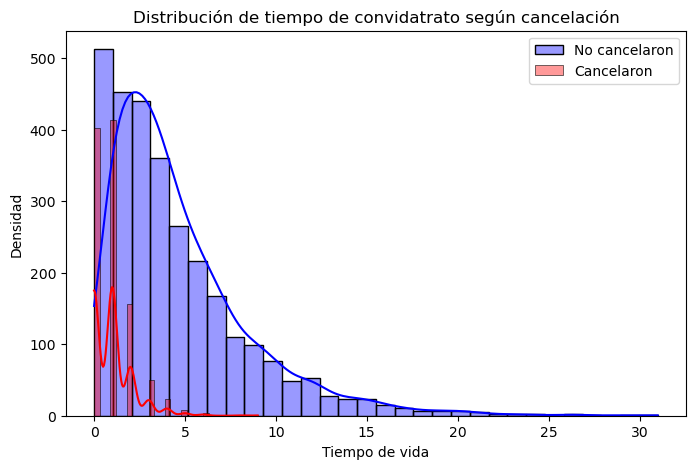

In [8]:
lifetime_0 = churn_0["Lifetime"]
lifetime_1 = churn_1["Lifetime"]

plt.figure(figsize=(8,5))

# Histogramas con línea de frecuencia
sns.histplot(lifetime_0, bins=30, kde=True, color='blue', label='No cancelaron', stat='count', alpha=0.4)
sns.histplot(lifetime_1, bins=30, kde=True, color='red', label='Cancelaron', stat='count', alpha=0.4)

plt.xlabel('Tiempo de vida')
plt.ylabel('Densidad')
plt.title('Distribución de tiempo de convidatrato según cancelación')
plt.legend()
plt.show()


Los suscriptores que permanecen en el gimnasio, presentan periodos de contrato más largos. En el grupo de permanencia, más del 50% excede los 4 meses de permanencia, mientras que en el grupo de cancelación el 75% de los usuarios permanece solamente 1 mes. Esto lo verificamos con la estadistica descriptiva pero también visualmente con el histograma.

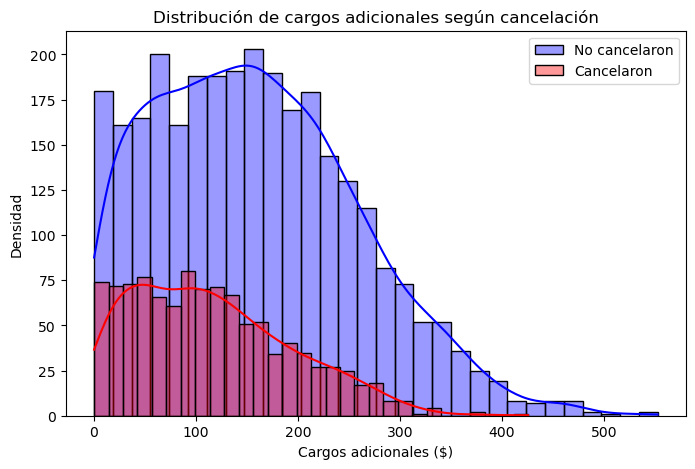

In [9]:
charge_0 = churn_0["Avg_additional_charges_total"]
charge_1 = churn_1["Avg_additional_charges_total"]

plt.figure(figsize=(8,5))

# Histogramas con línea de frecuencia
sns.histplot(charge_0, bins=30, kde=True, color='blue', label='No cancelaron', stat='count', alpha=0.4)
sns.histplot(charge_1, bins=30, kde=True, color='red', label='Cancelaron', stat='count', alpha=0.4)

plt.xlabel('Cargos adicionales ($)')
plt.ylabel('Densidad')
plt.title('Distribución de cargos adicionales según cancelación')
plt.legend()
plt.show()

Los ingresos percibidos por el gimnasio por cargos adicionales son mucho mayores (el doble) por el grupo que permanece. Tiende sentido porque a mayor tiempo de contrato mayores gastos adentro del gimnasio.

             Femenino  Masculino
Permanencia  0.489963   0.510037
Cancelacion  0.489161   0.510839


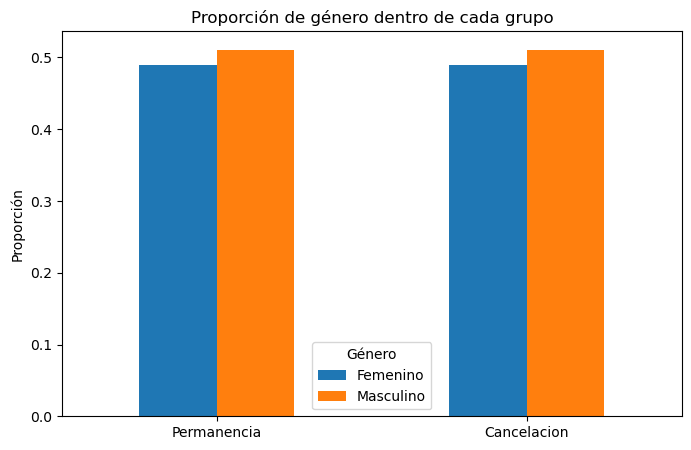

In [10]:
tabla = pd.crosstab(gym['Churn'], gym['gender'], normalize='index')
tabla.columns = ['Femenino', 'Masculino']  
tabla.index = ["Permanencia", "Cancelacion"]
print(tabla)

# Gráfica
tabla.plot(kind='bar', figsize=(8,5))

plt.title('Proporción de género dentro de cada grupo')
plt.xlabel('')
plt.ylabel('Proporción')
plt.legend(title='Género')
plt.xticks(rotation=0)
plt.show()

Todo parece indicar que el género, no es una variable relevante para el pronóstico de la permanencia en el gimnasio.

                                     gender  Near_Location   Partner  \
gender                             1.000000       0.006699 -0.010463   
Near_Location                      0.006699       1.000000 -0.005119   
Partner                           -0.010463      -0.005119  1.000000   
Promo_friends                     -0.005033       0.210964  0.451960   
Phone                             -0.008542      -0.015763  0.009970   
Contract_period                    0.000502       0.150233  0.306166   
Group_visits                       0.017879       0.154728  0.022710   
Age                                0.013807       0.058358  0.047480   
Avg_additional_charges_total      -0.009334       0.040761  0.022941   
Month_to_end_contract             -0.001281       0.143961  0.294632   
Lifetime                           0.013579       0.070921  0.061229   
Avg_class_frequency_total          0.014620       0.043127  0.024938   
Avg_class_frequency_current_month  0.009156       0.062664  0.04

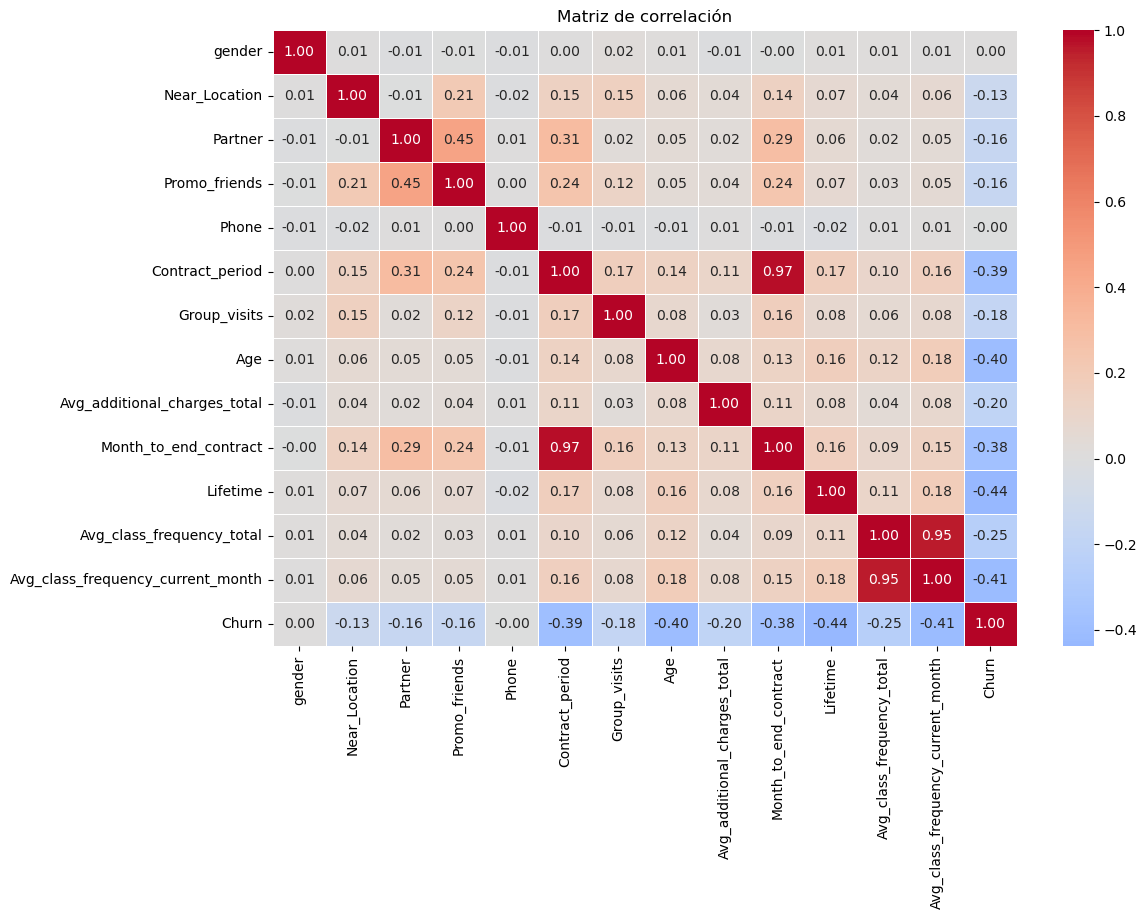

In [11]:
# Matriz de correlación para variables numéricas
corr_matrix = gym.corr(numeric_only=True)
print(corr_matrix)

# Mapa de calor
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix,
            annot=True,        
            fmt=".2f",         
            cmap="coolwarm",  
            center=0,         
            linewidths=0.5)

plt.title("Matriz de correlación")
plt.show()

De acuerdo a la matriz de correlación, las variables que presentan mayor relacion con la variable objetivo (Churn) son: Edad, Tiempo de permanencia, número de clases promedio semanales, tiempo de contrato y en menor medida, la cercanía, participación de clases grupales, suscripción códigos de empresas aliadas o amistades. Es importante resaltar que todas estas relaciones son negativas.

### MODELOS DE CLASIFICACIÓN

In [12]:
# Divido los datos variables objetivo y explicativas. También separo datos de entrenamiento y validación
X = gym.drop('Churn', axis = 1)
y = gym['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [13]:
# Primero debo escalar las variables numéricas
# Creo molde ara estandarizar
scaler = StandardScaler()
# Entreno el molde para escalar con datos de entrenamiento
scaler.fit(X_train)
# Transformo datos de entrenamiento y validación
X_train_st =scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

In [16]:
# Regresión Logística
# Defino el molde del modelo logístico
model = LogisticRegression(max_iter=1000)

# entrena tu modelo
model.fit(X_train, y_train)

# Encuentro pronósticos y probabilidades
ml_predictions = model.predict(X_test)
ml_probabilities = model.predict_proba(X_test)

In [14]:
# Bosque Aleatorio
# Defino el algoritmo para el nuevo modelo de random forest
rf_model = RandomForestClassifier(n_estimators = 100, random_state=0) # escribe tu código aquí
# Entreno el modelo
rf_model.fit(X_train_st, y_train)
# Calculo pronósticos y probabilidades
rf_predictions = rf_model.predict(X_test_st)# escribe tu código aquí
rf_probabilities = rf_model.predict_proba(X_test_st)[:,1]

In [17]:
# Métricas comparativas para modelos desarrollados
# Métricas para regresión logística
ml_accuracy = accuracy_score(y_test, ml_predictions)
ml_precision = precision_score(y_test, ml_predictions)
ml_recall = recall_score(y_test, ml_predictions)

# Métricas para bosque aleatorio
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)

# Organizo la información en una tabla:
# Creo diccionario con métricas
results = {
    "Modelo": ["Regresión Logística", "Bosque Aleatorio"],
    "Accuracy": [ml_accuracy, rf_accuracy],
    "Precision": [ml_precision, rf_precision],
    "Recall": [ml_recall, rf_recall]
}

# Convertir a DataFrame
metrics_table = pd.DataFrame(results)

metrics_table

,Modelo,Accuracy,Precision,Recall
0,Regresión Logística,0.92375,0.858639,0.828283
1,Bosque Aleatorio,0.91500,0.838542,0.813131


Ambos modelos nos dan una Exactitud (Accuracy) bastante alta, superior al 90%. Es decir, el 90 de las predicciones fueron acertadas en ambos modelos. El Recall es un 1% más alto en la Regresión Logística; esto sugiere que el primer modelo se acerca mucho más al número de usuarios que cancelan la suscripción. Este modelo puede ofrecer información importante para el desarrollo de estrategias que busquen disminuir el número de cancelaciones.

### MODELOS NO SUPERVISADOS PARA AGRUPAR CLIENTES

In [22]:
stats = gym.describe().T[['mean', 'std']]
print(stats)

# Estandarizo dataframe
scaler = StandardScaler()
# No debo separar el ataframe porque los modelos NO supervisados NO tienen variable objetivo
X_scaled = scaler.fit_transform(gym)

X_scaled = pd.DataFrame(X_scaled, columns=gym.columns, index=gym.index)
stats = X_scaled.describe().T[['mean', 'std']]
print(stats)

                                         mean        std
gender                               0.510250   0.499957
Near_Location                        0.845250   0.361711
Partner                              0.486750   0.499887
Promo_friends                        0.308500   0.461932
Phone                                0.903500   0.295313
Contract_period                      4.681250   4.549706
Group_visits                         0.412250   0.492301
Age                                 29.184250   3.258367
Avg_additional_charges_total       146.943728  96.355602
Month_to_end_contract                4.322750   4.191297
Lifetime                             3.724750   3.749267
Avg_class_frequency_total            1.879020   0.972245
Avg_class_frequency_current_month    1.767052   1.052906
Churn                                0.265250   0.441521
                                           mean       std
gender                             7.771561e-17  1.000125
Near_Location                

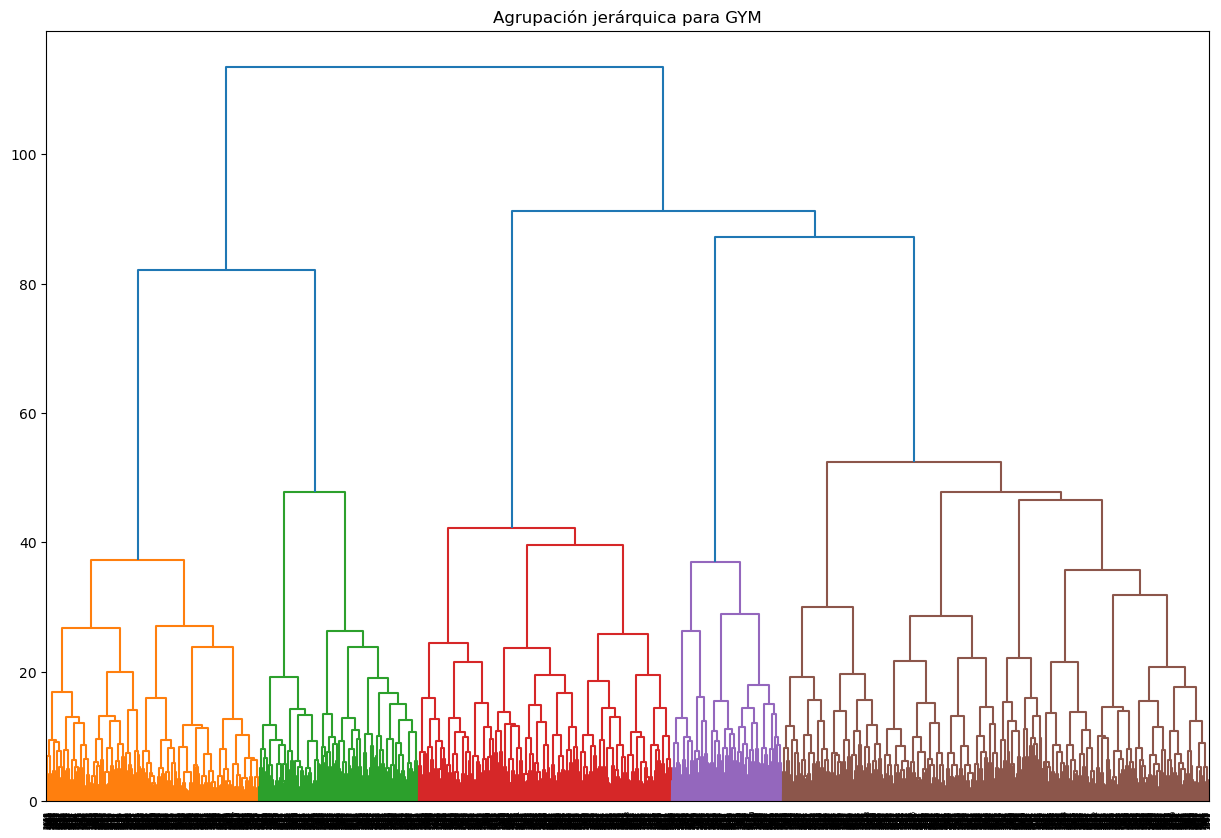

In [23]:
# Creo dendograma para ver grupos de clientes (Clustering jerárquico aglomerativo)
linked = linkage(X_scaled, method = 'ward')

# Gráfico del dendograma
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Agrupación jerárquica para GYM')
plt.show()

Mediante el dendograma, podemos identificar claramente 5 grupos detectados por el algortimo: café, morado, rojo, verde y naranja. El café es el que tiene un mayor número de usuarios.

In [ ]:
# Ahora sí puedo crear el modelo kmeans, utilizando 5 como número de clusters
km = KMeans(n_clusters = 5) 
labels = km.fit_predict(X_scaled) 

# Guardo los grupos en el dataset
gym['cluster'] = labels
print(gym.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

ANÁLISIS DE LOS GRUPOS

In [25]:
# ¿Cuál es el tamaño/proporción de los grupos?
print(gym['cluster'].value_counts().sort_index())
print(gym['cluster'].value_counts(normalize=True).sort_index())

cluster
0    984
1    703
2    546
3    836
4    931
Name: count, dtype: int64
cluster
0    0.24600
1    0.17575
2    0.13650
3    0.20900
4    0.23275
Name: proportion, dtype: float64


Los grupos son relativamente parejos, en cuanto a la proporcion. Cada uno representa entre el 13% y 24% del conjunto completo.

           gender  Near_Location   Partner  Promo_friends     Phone  \
cluster                                                               
0        0.537602       0.990854  0.137195       0.041667  0.907520   
1        0.487909       0.988620  0.883357       0.758179  0.890469   
2        0.501832       0.000000  0.461538       0.067766  0.917582   
3        0.507177       1.000000  0.313397       0.202153  0.901914   
4        0.505908       0.939850  0.727175       0.487648  0.902256   

         Contract_period  Group_visits        Age  \
cluster                                             
0               2.508130      0.449187  30.234756   
1               3.625889      0.482219  29.995733   
2               2.142857      0.210623  28.521978   
3               1.641148      0.284689  26.937799   
4              11.993555      0.553169  29.866810   

         Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
cluster                                                 

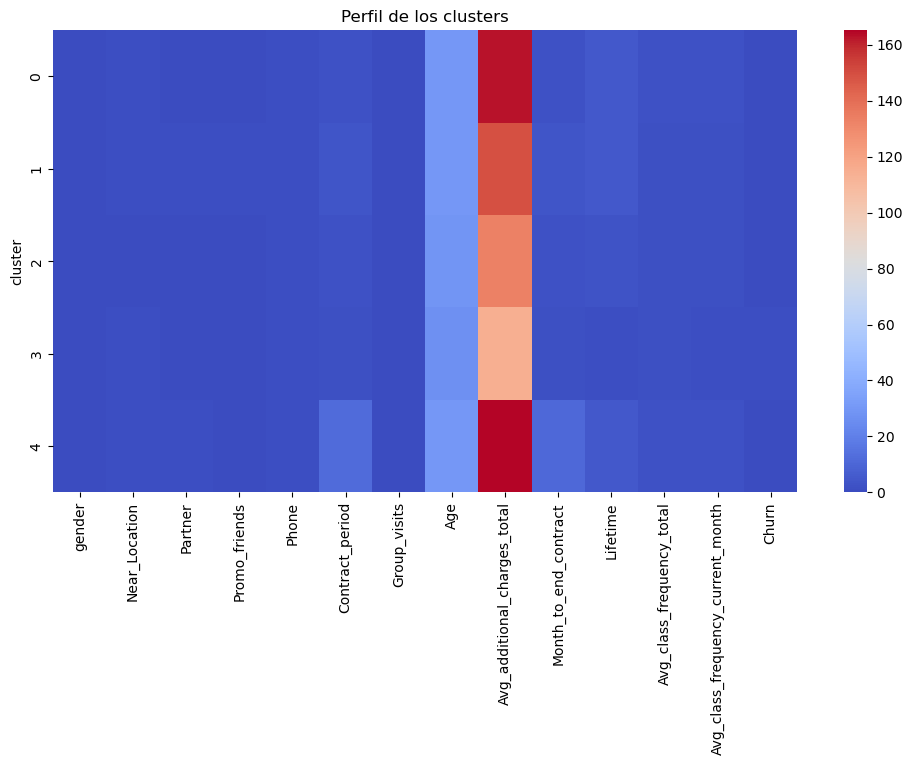

La tasa de cancelación por grupo es:
cluster
3    0.940191
2    0.448718
4    0.016112
1    0.014225
0    0.005081
Name: Churn, dtype: float64


In [30]:
# Perfil de cada cluster
cluster_profile = gym.groupby('cluster').mean()
print(cluster_profile)

# Gráfico
plt.figure(figsize=(12,6))
sns.heatmap(cluster_profile, annot=False, cmap='coolwarm')
plt.title('Perfil de los clusters')
plt.show()

# Cual es la tasa de cancelación de cada grupo?
print("La tasa de cancelación por grupo es:")
pd.set_option('display.max_columns', None)
print(cluster_profile['Churn'].sort_values(ascending=False))

#### ANÁLISIS DE GRUPOS
Cluster 0 "LOS MÁS ANTIGUOS Y FIELES" El grupo 0, es el grupo con mayor edad promedio. Este grupo de personas se caracteriza por vivir cerca del gimnasio, sin embargo, no utilizan los códigos de promoción (alianzas empresariales o amigos) para su suscripción. A pesar de esto, son el grupo con menor tasa de cancelación de suscripción (0.5%). EL GRUPO CERO ES EL MÁS FIEL Y ANTIGUO DEL GIMNASIO. A pesar de elsu fidelidad, los usuarios de este grupo prefieren tener contratos más cortos (menos de 3 meses).

Cluster 1 "LOS QUE USAN CÓDIGOS DE PROMOCIÓN, SON FIELES Y PREFIEREN CONTRATOS CORTOS" El grupo 1, también corresponden a usuarios de mayor edad (29.9 años promedio), pero a diferencia del Cluster 0, este grupo utiliza en gran medida los códigos de promoción (88% alianzas empresariales, 75% por amistad). A diferencia del cluster 0, los usuarios de este grupo prefieren periodos de contrato mayores a los 3 meses, sin embargo, esto puede estar relacionado con las condiciones de la promoción. Estos usuarios también presentan un Lifetime alto.

Cluster 2 "LOS QUE USAN CÓDIGO EMPRESARIAL PERO VIVEN LEJOS". El 100% de usuarios de este grupo viven lejos del gimnasio, sin embargo, más del 40% vienen de una empresa aliada. Su periodo de permanencia en el gimnasio (Lifetime) no es el más bajo pero tampoco es alto, sim embargo, si tasa de cancelación es alta, mayor al 40%. Su rango de edad es medio, no es muy alto pero tampoco es muy bajo. Su participación en clases grupales no es alta, posiblemente por los conflictos horarios.

Cluser 3 "EL GRUPO MÁS JOVEN CON MAYOR TASA DE CANCELANCIÓN EN LA SUSCRIPCIÓN" Este grupo se caracteriza por contener a los más jóvenes de los suscriptores (26 años promedio). A pesar de que el 100% de los usuarios de este grupo viven cerca del gimnasio, la tasa de cancelación es superior al 90% y en consecuencia su periodo de vida o lifetime es el más bajo de la empresa. Su tasa de participación en clases grupales es baja. Esto puede estar relacionado con las expectativas de las personas jóvenes y sus preferencias en la interacción con el gimnasio.

Cluster 4 "LOS QUE USAN CÓDIGO DE PROMOCIÓN, SON FIELES Y PREFIEREN CONTRATOS LARGOS" Este grupo se parece mucho al Cluster 1, y la diferencia está en el tiempo de contrato, el cual es superior a los 11 meses en promedio.

Es común que los grupos más fieles Cluster 0, 1 y 4 valoran en gran medida las clases grupales, contrastando con los grupos menos fieles  Cluster 2 y 3.

HISTOGRAMAS POR CLUSTERS

In [31]:
fig = px.histogram(
    gym,
    x="Age",                 # variable que quieres analizar
    color="cluster",         # separa por cluster
    barmode="overlay",       # superpone histogramas
    opacity=0.6,             # transparencia
    nbins=30,
    marginal="box",          # mini boxplot arriba (opcional, pero buenísimo)
    title="Distribución de Edad por Cluster"
)

fig.update_layout(
    template="plotly_white",
    legend_title="Cluster"
)

fig.show()

El histograma anterior, nos permite visualizar, la conclusión del análisis anterior, en donde veíamos qye lios grupos más fieles (Cluster 0, 1 y 4) están conformados por personas de mayor edad.

### CONCLUSIONES Y RECOMENDACIONES
A través de los análisis identificamos que las variables o aspectos más relevantes para la permanencia de los usuarios en el gimnasio son: la cercanía, códigos de promoción y las clases grupales. Esta identificación fue más fácil de observar en el agrupamiento mediante modelos NO supervisados. La matriz de correlación confirmaba esto mismo pero no con coeficientes tan contundentes. 

Si bien la permanencia de los usuarios del Cluster 0, 1 y 4 es bastante alta, se podría optar por estrategias que favorezcan la continuidad de los usuarios de los grupos 2 y 3, es decir, estrategias para personas más jóvenes y usuarios empleados de empresas aliadas pero que viven lejos. Para los jóvenes se podrían plantear retos que motiven la asistencia semanal y por consecuencia la permanencia. Por ejemplo, el gimnasio podría ofrecer baridos proteicos a aquellos suscriptores que cumplan con la rutina diaria planteada. Para los empresarios lejanos, el gimnasio puede proponerle a las empresas aliadas, pequeñas rutinas o clases dentro del horario laboral.